In [1]:

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Save model
import joblib

# XGBoost
from xgboost import XGBClassifier


**Dataset Preparation for ML**

In [2]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

# Move from models/ to project root
project_root = os.path.dirname(os.getcwd())

# Build correct path
data_path = os.path.join(
    project_root,
    "data",
    "processed",
    "preprocessed_new.csv"
)

# Load dataset
df = pd.read_csv(data_path)

print(df.shape)


(29346, 15)


In [3]:
print("Dataset shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nTarget distribution:")
print(df["target"].value_counts())



Dataset shape: (29346, 15)

Columns:
 Index(['pl_rade', 'pl_orbper', 'pl_orbsmax', 'pl_eqt', 'pl_dens', 'st_teff',
       'st_lum', 'st_met', 'habitability_score', 'stellar_compatibility',
       'orbital_stability', 'star_F', 'star_G', 'star_K', 'target'],
      dtype='object')

Target distribution:
target
0    27552
1     1794
Name: count, dtype: int64


**Target Variable**

In [4]:

# df["target"] = 0

# df.loc[
#     (df["pl_rade"].between(0.5, 2.0)) &         # Rocky size
#     (df["pl_bmasse"] < 10) &                   # Not gas giant
#     (df["pl_eqt"].between(230, 310)) &         # Liquid water temp
#     (df["pl_orbsmax"].between(0.3, 2.0)),      # Habitable zone approx
#     "target"
# ] = 1

# ---------------------------------------------
# Binary Habitability Target (Updated)
# ---------------------------------------------

df["target"] = 0

df.loc[
    (df["pl_eqt"].between(180, 320)) &   # Liquid water zone
    (df["pl_rade"].between(0.5, 2.0)) &  # Rocky planets
    (df["pl_orbsmax"].between(0.3, 2.0)), # Habitable zone AU
    "target"
] = 1

# Check distribution
print(df["target"].value_counts())
print(df["target"].value_counts(normalize=True) * 100)




target
0    27552
1     1794
Name: count, dtype: int64
target
0    93.886731
1     6.113269
Name: proportion, dtype: float64


In [5]:
print(df["pl_eqt"].describe())
print(df["pl_orbsmax"].describe())
print(df["pl_rade"].describe())


count    29346.000000
mean       511.682098
std        342.862896
min         34.000000
25%        288.000000
50%        288.000000
75%        699.000000
max       1315.500000
Name: pl_eqt, dtype: float64
count    29346.000000
mean         0.631203
std          0.550515
min          0.004400
25%          0.088500
50%          1.000000
75%          1.000000
max          2.367250
Name: pl_orbsmax, dtype: float64
count    29346.000000
mean         2.425978
std          0.778631
min          0.970000
25%          2.020000
50%          2.370000
75%          2.720000
max          3.770000
Name: pl_rade, dtype: float64


In [6]:
print("Radius:", df["pl_rade"].between(0.5, 2.0).sum())
print("Temp:", df["pl_eqt"].between(230, 310).sum())
print("AU:", df["pl_orbsmax"].between(0.3, 2.0).sum())


Radius: 7243
Temp: 17840
AU: 15470


**Separate Features (X) and Target (y)**

In [7]:
# Separate input features and target
X = df.drop(columns=[
    "target",
    "habitability_score",
    "stellar_compatibility",
    "orbital_stability",
    "pl_eqt",
    "pl_rade",
    "pl_orbsmax",
])

y = df["target"]


# Verify separation
print("Features shape (X):", X.shape)
print("Target shape (y):", y.shape)

print("\nTarget distribution:")
print(y.value_counts())


Features shape (X): (29346, 8)
Target shape (y): (29346,)

Target distribution:
target
0    27552
1     1794
Name: count, dtype: int64


In [8]:
X.columns

Index(['pl_orbper', 'pl_dens', 'st_teff', 'st_lum', 'st_met', 'star_F',
       'star_G', 'star_K'],
      dtype='object')

**Train–Test Split (80–20) with Reproducibility**

In [9]:
# Train-test split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Verify split
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())


X_train shape: (23476, 8)
X_test shape: (5870, 8)

Training target distribution:
target
0    22041
1     1435
Name: count, dtype: int64

Testing target distribution:
target
0    5511
1     359
Name: count, dtype: int64


In [10]:
# -----------------------------------------
# Handle Class Imbalance using SMOTE
# -----------------------------------------
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)

X_train, y_train = sm.fit_resample(X_train, y_train)

print("After SMOTE:")
print(y_train.value_counts())


After SMOTE:
target
0    22041
1    22041
Name: count, dtype: int64


C:\Users\Sanjana Malkhede\anaconda3\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


**Scaling**

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


**Baseline Model — Logistic Regression**

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

log_reg = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    solver="lbfgs"
)

log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)

print("Logistic Regression (balanced)")
print(classification_report(y_test, y_pred_lr))


Logistic Regression (balanced)
              precision    recall  f1-score   support

           0       0.96      0.55      0.70      5511
           1       0.08      0.62      0.14       359

    accuracy                           0.56      5870
   macro avg       0.52      0.58      0.42      5870
weighted avg       0.90      0.56      0.67      5870



**Baseline Model: Decision Tree (Shallow)**

In [13]:

from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42
)

dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("Decision Tree (regularized)")
print(classification_report(y_test, y_pred_dt))


Decision Tree (regularized)
              precision    recall  f1-score   support

           0       0.97      0.66      0.78      5511
           1       0.11      0.67      0.20       359

    accuracy                           0.66      5870
   macro avg       0.54      0.67      0.49      5870
weighted avg       0.92      0.66      0.75      5870



**Random Forest**

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Final Random Forest model
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=10,
    class_weight={0: 1, 1: 3},
    random_state=42,
    n_jobs=-1
)

# Train
rf.fit(X_train, y_train)

# Predict probabilities
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# ✅ FINAL THRESHOLD (selected after analysis)
FINAL_THRESHOLD = 0.4

# Final predictions
y_pred_rf_final = (y_prob_rf >= FINAL_THRESHOLD).astype(int)

# Evaluation
print("Final Random Forest Model (threshold = 0.4)")
print(classification_report(y_test, y_pred_rf_final))


Final Random Forest Model (threshold = 0.4)
              precision    recall  f1-score   support

           0       0.98      0.48      0.64      5511
           1       0.10      0.84      0.17       359

    accuracy                           0.50      5870
   macro avg       0.54      0.66      0.41      5870
weighted avg       0.93      0.50      0.62      5870



**XGBoost Classifier**

In [15]:

# 1. Handle class imbalance
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# 2. Define XGBoost model
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    reg_alpha=0.1,
    reg_lambda=1,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

# 3. Train model

xgb.fit(X_train, y_train)

# 4. Predict probabilities
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

FINAL_XGB_THRESHOLD = 0.5

y_pred_xgb_final = (y_prob_xgb >= FINAL_XGB_THRESHOLD).astype(int)

print("Final XGBoost Model (threshold = 0.5)")
print(classification_report(y_test, y_pred_xgb_final))



Final XGBoost Model (threshold = 0.5)
              precision    recall  f1-score   support

           0       0.96      0.79      0.87      5511
           1       0.14      0.55      0.23       359

    accuracy                           0.77      5870
   macro avg       0.55      0.67      0.55      5870
weighted avg       0.91      0.77      0.83      5870



Pipeline for Logistic Regression

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Logistic Regression Pipeline
log_reg_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

# Train
log_reg_pipe.fit(X_train, y_train)

# Predict
y_pred_lr = log_reg_pipe.predict(X_test)

print("Logistic Regression Pipeline Report")
print(classification_report(y_test, y_pred_lr))


Logistic Regression Pipeline Report
              precision    recall  f1-score   support

           0       0.96      0.55      0.70      5511
           1       0.08      0.62      0.14       359

    accuracy                           0.56      5870
   macro avg       0.52      0.58      0.42      5870
weighted avg       0.90      0.56      0.67      5870



Pipeline for Random Forest

In [17]:
from sklearn.ensemble import RandomForestClassifier

rf_pipe = Pipeline([
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=10,
        class_weight={0:1, 1:3},
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipe.fit(X_train, y_train)

y_prob_rf = rf_pipe.predict_proba(X_test)[:, 1]

FINAL_RF_THRESHOLD = 0.4
y_pred_rf_final = (y_prob_rf >= FINAL_RF_THRESHOLD).astype(int)

print("Random Forest Pipeline Report")
print(classification_report(y_test, y_pred_rf_final))


Random Forest Pipeline Report
              precision    recall  f1-score   support

           0       0.98      0.48      0.64      5511
           1       0.10      0.84      0.17       359

    accuracy                           0.50      5870
   macro avg       0.54      0.66      0.41      5870
weighted avg       0.93      0.50      0.62      5870



Pipeline for XGBoost

In [18]:
from xgboost import XGBClassifier

scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

xgb_pipe = Pipeline([
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        reg_alpha=0.1,
        reg_lambda=1,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42
    ))
])

xgb_pipe.fit(X_train, y_train)

y_prob_xgb = xgb_pipe.predict_proba(X_test)[:, 1]

FINAL_XGB_THRESHOLD = 0.5
y_pred_xgb_final = (y_prob_xgb >= FINAL_XGB_THRESHOLD).astype(int)

print("XGBoost Pipeline Report")
print(classification_report(y_test, y_pred_xgb_final))


XGBoost Pipeline Report
              precision    recall  f1-score   support

           0       0.96      0.79      0.87      5511
           1       0.14      0.55      0.23       359

    accuracy                           0.77      5870
   macro avg       0.55      0.67      0.55      5870
weighted avg       0.91      0.77      0.83      5870




===== Random Forest (Default) Evaluation =====
Accuracy : 0.8701873935264055
Precision: 0.18662519440124417
Recall   : 0.3342618384401114
F1-score : 0.23952095808383234
ROC-AUC  : 0.7602442620456731

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.91      0.93      5511
           1       0.19      0.33      0.24       359

    accuracy                           0.87      5870
   macro avg       0.57      0.62      0.58      5870
weighted avg       0.91      0.87      0.89      5870


Confusion Matrix:
[[4988  523]
 [ 239  120]]

===== XGBoost (Default) Evaluation =====
Accuracy : 0.8371379897785349
Precision: 0.15331010452961671
Recall   : 0.36768802228412256
F1-score : 0.21639344262295082
ROC-AUC  : 0.7368056998183932

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.87      0.91      5511
           1       0.15      0.37      0.22       359

    accuracy        

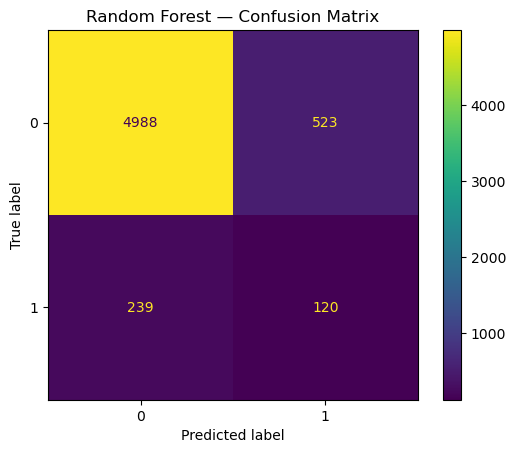

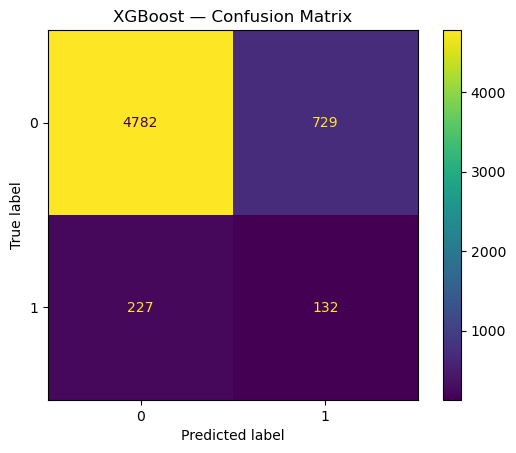

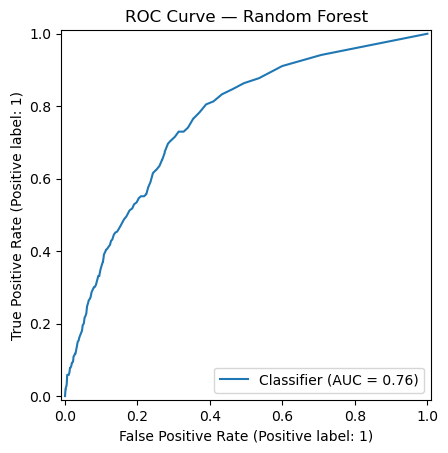

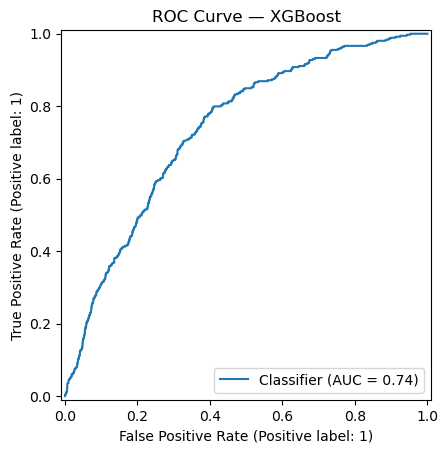


Models saved successfully in /models folder.


In [19]:
# =========================================================
# STEP 6 & 7 — Default Model Training, Saving & Evaluation
# =========================================================

# Imports
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)
import matplotlib.pyplot as plt
import joblib
import os

# ---------------------------------------------------------
# 1. Train Default Random Forest
# ---------------------------------------------------------
rf_default = RandomForestClassifier(
    random_state=42
)

rf_default.fit(X_train, y_train)

y_pred_rf = rf_default.predict(X_test)
y_prob_rf = rf_default.predict_proba(X_test)[:, 1]


# ---------------------------------------------------------
# 2. Train Default XGBoost
# ---------------------------------------------------------
xgb_default = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb_default.fit(X_train, y_train)

y_pred_xgb = xgb_default.predict(X_test)
y_prob_xgb = xgb_default.predict_proba(X_test)[:, 1]


# ---------------------------------------------------------
# 3. Evaluation Function
# ---------------------------------------------------------
def evaluate_model(y_true, y_pred, y_prob, model_name):
    
    print(f"\n===== {model_name} Evaluation =====")
    
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1-score :", f1_score(y_true, y_pred))
    print("ROC-AUC  :", roc_auc_score(y_true, y_prob))
    
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))
    
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))


# ---------------------------------------------------------
# 4. Evaluate Models
# ---------------------------------------------------------
evaluate_model(y_test, y_pred_rf, y_prob_rf, "Random Forest (Default)")
evaluate_model(y_test, y_pred_xgb, y_prob_xgb, "XGBoost (Default)")


# ---------------------------------------------------------
# 5. Confusion Matrix Plots
# ---------------------------------------------------------
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Random Forest — Confusion Matrix")
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb)
plt.title("XGBoost — Confusion Matrix")
plt.show()


# ---------------------------------------------------------
# 6. ROC Curve Plots
# ---------------------------------------------------------
RocCurveDisplay.from_predictions(y_test, y_prob_rf)
plt.title("ROC Curve — Random Forest")
plt.show()

RocCurveDisplay.from_predictions(y_test, y_prob_xgb)
plt.title("ROC Curve — XGBoost")
plt.show()


# ---------------------------------------------------------
# 7. Save Models
# ---------------------------------------------------------
import os

# Move to project root
project_root = os.path.dirname(os.getcwd())
os.chdir(project_root)

os.makedirs("models", exist_ok=True)


joblib.dump(rf_default, "models/random_forest.pkl")
joblib.dump(xgb_default, "models/xgboost1.pkl")

print("\nModels saved successfully in /models folder.")


Random Forest RandomizedSearch

In [20]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

# Parameter distribution
rf_param_dist = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [6, 10, 12, 16],
    "min_samples_leaf": [1, 5, 10, 20],
    "class_weight": [
        {0:1, 1:1},
        {0:1, 1:2},
        {0:1, 1:3}
    ]
}

# Base model
rf_base = RandomForestClassifier(random_state=42)

# Randomized Search
rf_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=rf_param_dist,
    n_iter=20,
    scoring="recall",
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

# Train search
rf_search.fit(X_train, y_train)

# Best model
rf_tuned = rf_search.best_estimator_

print("Best RF Parameters:")
print(rf_search.best_params_)


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best RF Parameters:
{'n_estimators': 400, 'min_samples_leaf': 20, 'max_depth': 6, 'class_weight': {0: 1, 1: 3}}


In [21]:
from sklearn.metrics import classification_report

y_pred_rf_tuned = rf_tuned.predict(X_test)
y_prob_rf_tuned = rf_tuned.predict_proba(X_test)[:, 1]

print("Tuned Random Forest Report")
print(classification_report(y_test, y_pred_rf_tuned))


Tuned Random Forest Report
              precision    recall  f1-score   support

           0       0.98      0.30      0.46      5511
           1       0.08      0.92      0.15       359

    accuracy                           0.34      5870
   macro avg       0.53      0.61      0.30      5870
weighted avg       0.93      0.34      0.44      5870



In [22]:
from xgboost import XGBClassifier

xgb_param_dist = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}

xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_param_dist,
    n_iter=20,
    scoring="recall",
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

xgb_search.fit(X_train, y_train)

xgb_tuned = xgb_search.best_estimator_

print("Best XGBoost Parameters:")
print(xgb_search.best_params_)


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best XGBoost Parameters:
{'subsample': 0.8, 'n_estimators': 400, 'max_depth': 6, 'learning_rate': 0.01, 'colsample_bytree': 1.0}


In [23]:
y_pred_xgb_tuned = xgb_tuned.predict(X_test)
y_prob_xgb_tuned = xgb_tuned.predict_proba(X_test)[:, 1]

print("Tuned XGBoost Report")
print(classification_report(y_test, y_pred_xgb_tuned))


Tuned XGBoost Report
              precision    recall  f1-score   support

           0       0.97      0.74      0.84      5511
           1       0.14      0.62      0.22       359

    accuracy                           0.74      5870
   macro avg       0.55      0.68      0.53      5870
weighted avg       0.92      0.74      0.80      5870



In [24]:
import os

# Move to project root
project_root = os.path.dirname(os.getcwd())
os.chdir(project_root)

os.makedirs("models", exist_ok=True)


In [25]:
import joblib

joblib.dump(rf_tuned, "models/random_forest_tuned.pkl")
joblib.dump(xgb_tuned, "models/xgboost_tuned.pkl")

print("Tuned models saved.")


Tuned models saved.


Model Comparison

In [26]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

def add_results(name, y_true, y_pred):
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred)
    })

# Default models
add_results("Random Forest (Default)", y_test, y_pred_rf)
add_results("XGBoost (Default)", y_test, y_pred_xgb)

# Tuned models
add_results("Random Forest (Tuned)", y_test, y_pred_rf_tuned)
add_results("XGBoost (Tuned)", y_test, y_pred_xgb_tuned)

# Final threshold models
y_pred_rf_final = (y_prob_rf >= 0.4).astype(int)
y_pred_xgb_final = (y_prob_xgb >= 0.5).astype(int)

add_results("Random Forest (Final)", y_test, y_pred_rf_final)
add_results("XGBoost (Final)", y_test, y_pred_xgb_final)

# Display comparison
comparison_df = pd.DataFrame(results)
comparison_df.sort_values(by="Recall", ascending=False)


,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest (Tuned),0.337649,0.078778,0.919220,0.145119
3,XGBoost (Tuned),0.735264,0.135893,0.621170,0.223000
4,Random Forest (Final),0.842930,0.177549,0.431755,0.251623
1,XGBoost (Default),0.837138,0.153310,0.367688,0.216393
5,XGBoost (Final),0.837138,0.153310,0.367688,0.216393
0,Random Forest (Default),0.870187,0.186625,0.334262,0.239521


**Habitability Scoring & Ranking**

In [27]:

# STEP 10 — Habitability Scoring & Ranking
import pandas as pd
import os

# Ensure correct folder
os.makedirs("data/processed", exist_ok=True)


# 1. Train final model on FULL dataset

rf_final = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=10,
    class_weight={0:1, 1:3},
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X, y)   # Train on full data

# 2. Generate habitability probabilities

habitability_scores = rf_final.predict_proba(X)[:, 1]

df["habitability_score"] = habitability_scores

# 3. Rank planets

df_ranked = df.sort_values(
    by="habitability_score",
    ascending=False
)

df_ranked["habitability_rank"] = range(1, len(df_ranked) + 1)


# ---------------------------------------------------------
# 4. Save ranked dataset
# ---------------------------------------------------------
os.makedirs("data/processed", exist_ok=True)

df_ranked.to_csv(
    "data/processed/habitability_ranked_rf.csv",
    index=False
)

print("Habitability ranking file saved successfully.")


Habitability ranking file saved successfully.


**Feature Importance**

In [28]:
# =========================================================
# STEP 11 — Model Interpretability
# Feature Importance
# =========================================================

import pandas as pd
import matplotlib.pyplot as plt

# Extract feature importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_final.feature_importances_
})

# Sort descending
importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)


     Feature  Importance
4     st_met    0.364945
0  pl_orbper    0.349576
2    st_teff    0.262715
7     star_K    0.010210
5     star_F    0.008159
6     star_G    0.004395
1    pl_dens    0.000000
3     st_lum    0.000000


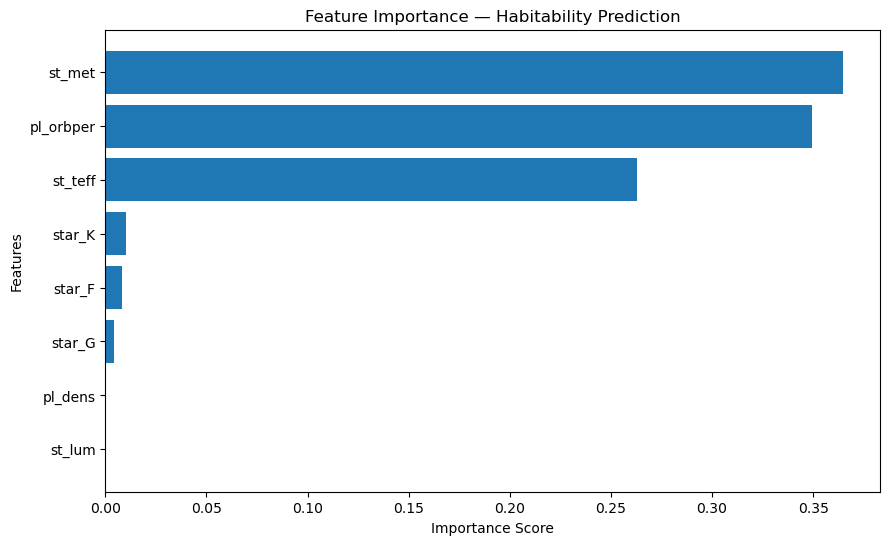

In [29]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Feature Importance — Habitability Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()
